# Notebook 08: Workforce Health Index (WHI)

---

## Objective

This notebook develops a **Workforce Health Index (WHI)** -- a composite metric that quantifies the overall well-being and engagement health of each employee on a 0-100 scale. The WHI synthesizes multiple dimensions of the employee experience into a single, actionable score that can be used for:

- Early identification of at-risk employees before they disengage or leave
- Department-level benchmarking and comparison
- Tracking workforce health trends over time
- Prioritizing interventions and resource allocation
- Providing leadership with a clear, interpretable health metric

---

## Business Questions

1. Can we construct a single composite score that meaningfully captures employee well-being?
2. How should different dimensions be weighted -- equally or based on their predictive power?
3. Does the WHI effectively differentiate between employees who leave and those who stay?
4. What does the distribution of workforce health look like across the organization?
5. Which departments or work models show the highest/lowest workforce health?
6. Can we define actionable risk categories based on WHI thresholds?

---

## Methodology

### Conceptual Framework

The Workforce Health Index is inspired by composite indices used in public health (e.g., the Human Development Index) and organizational psychology. The key principles are:

1. **Multi-dimensional**: No single survey item captures the full employee experience
2. **Normalized**: Variables on different scales must be made comparable
3. **Weighted**: Not all dimensions contribute equally to outcomes
4. **Validated**: The index must demonstrably relate to real outcomes (attrition)
5. **Interpretable**: Scores and categories must be actionable for business leaders

### Approach

1. Select variables representing key dimensions of workforce health
2. Normalize all variables to a common 0-1 scale using Min-Max scaling
3. Derive data-driven weights using point-biserial correlation with attrition
4. Compute the weighted composite index (scaled 0-100)
5. Validate the index against actual attrition outcomes
6. Define risk categories with actionable thresholds

---

## 1. Setup and Data Loading

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Statistical methods
from scipy.stats import pointbiserialr, mannwhitneyu

# Machine learning utilities
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, auc

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Plot styling
sns.set_style('whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load the augmented dataset
data_path = '../data/processed/employee_attrition_augmented.csv'
df = pd.read_csv(data_path)

print(f'Dataset shape: {df.shape}')
print(f'Number of employees: {len(df)}')
print(f'Number of features: {df.shape[1]}')
print(f'\nAttrition distribution:')
print(df['Attrition'].value_counts())
print(f'\nAttrition rate: {(df["Attrition"] == "Yes").mean()*100:.1f}%')

Dataset shape: (1470, 43)
Number of employees: 1470
Number of features: 43

Attrition distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1%


In [3]:
# Encode Attrition as binary for analysis
df['Attrition_Binary'] = (df['Attrition'] == 'Yes').astype(int)

print('Attrition binary encoding:')
print(f'  No (stayed)  -> 0: {(df["Attrition_Binary"] == 0).sum()} employees')
print(f'  Yes (left)   -> 1: {(df["Attrition_Binary"] == 1).sum()} employees')

Attrition binary encoding:
  No (stayed)  -> 0: 1233 employees
  Yes (left)   -> 1: 237 employees


---

## 2. Variable Selection for WHI

The WHI is built from seven dimensions that collectively capture the employee experience. These variables were selected based on:

- **Theoretical grounding**: Each represents a well-established construct in organizational psychology
- **Coverage**: Together they span workload, relationships, growth, satisfaction, and engagement
- **Measurability**: All are quantitative scores available in the dataset
- **Actionability**: Organizations can influence each dimension through targeted interventions

### Selected Dimensions

| Dimension | Variable | Scale | Direction | Rationale |
|-----------|----------|-------|-----------|----------|
| Workload Sustainability | WorkloadScore | 1-5 | **INVERTED** | Higher workload reduces health |
| Work-Life Balance | WorkLifeBalance | 1-4 | Direct | Balance supports well-being |
| Manager Support | ManagerSupportScore | 1-5 | Direct | Good management retains talent |
| Career Growth | CareerGrowthPerception | 1-5 | Direct | Growth opportunities drive engagement |
| Job Satisfaction | JobSatisfaction | 1-4 | Direct | Core measure of contentment |
| Compensation Satisfaction | CompensationSatisfaction | 1-5 | Direct | Fair pay supports retention |
| Job Involvement | JobInvolvement | 1-4 | Direct | Engagement with one's role |

**Note on WorkloadScore inversion**: A high workload score (e.g., 5) indicates excessive workload, which is detrimental to health. We invert this so that the contribution aligns with the other variables (higher = healthier).

In [4]:
# Define WHI component variables
whi_variables = [
    'WorkloadScore',
    'WorkLifeBalance',
    'ManagerSupportScore',
    'CareerGrowthPerception',
    'JobSatisfaction',
    'CompensationSatisfaction',
    'JobInvolvement'
]

# Check that all variables exist in the dataset
print('Variable availability check:')
for var in whi_variables:
    if var in df.columns:
        print(f'  [OK] {var} - Range: [{df[var].min()}, {df[var].max()}], Missing: {df[var].isna().sum()}')
    else:
        print(f'  [MISSING] {var}')

Variable availability check:
  [OK] WorkloadScore - Range: [1, 5], Missing: 0
  [OK] WorkLifeBalance - Range: [1, 4], Missing: 0
  [OK] ManagerSupportScore - Range: [1, 5], Missing: 0
  [OK] CareerGrowthPerception - Range: [1, 5], Missing: 0
  [OK] JobSatisfaction - Range: [1, 4], Missing: 0
  [OK] CompensationSatisfaction - Range: [1, 5], Missing: 0
  [OK] JobInvolvement - Range: [1, 4], Missing: 0


In [5]:
# Descriptive statistics for WHI component variables
print('Descriptive Statistics for WHI Components:')
print('=' * 70)
df[whi_variables].describe().round(3)

Descriptive Statistics for WHI Components:


,WorkloadScore,WorkLifeBalance,ManagerSupportScore,CareerGrowthPerception,JobSatisfaction,CompensationSatisfaction,JobInvolvement
count,1470.0000,1470.0000,1470.0000,1470.0000,1470.0000,1470.0000,1470.0000
mean,3.4560,2.7610,3.4860,3.3330,2.7290,3.3970,2.7300
std,0.9260,0.7060,0.9420,0.9870,1.1030,0.9440,0.7120
min,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
25%,3.0000,2.0000,3.0000,3.0000,2.0000,3.0000,2.0000
50%,3.0000,3.0000,4.0000,3.0000,3.0000,3.0000,3.0000
75%,4.0000,3.0000,4.0000,4.0000,4.0000,4.0000,3.0000
max,5.0000,4.0000,5.0000,5.0000,4.0000,5.0000,4.0000


In [6]:
# Invert WorkloadScore: higher workload = lower health
# Transformation: 6 - WorkloadScore (since max is 5, this maps 5->1, 4->2, 3->3, 2->4, 1->5)
df['WorkloadScore_Inverted'] = 6 - df['WorkloadScore']

print('WorkloadScore Inversion:')
print(f'  Original range: [{df["WorkloadScore"].min()}, {df["WorkloadScore"].max()}]')
print(f'  Inverted range: [{df["WorkloadScore_Inverted"].min()}, {df["WorkloadScore_Inverted"].max()}]')
print(f'\n  Mapping: Original -> Inverted')
for val in sorted(df['WorkloadScore'].unique()):
    print(f'    {val} -> {6 - val}')
print(f'\n  Interpretation: Now higher values = more sustainable workload = healthier')

WorkloadScore Inversion:
  Original range: [1, 5]
  Inverted range: [1, 5]

  Mapping: Original -> Inverted
    1 -> 5
    2 -> 4
    3 -> 3
    4 -> 2
    5 -> 1

  Interpretation: Now higher values = more sustainable workload = healthier


---

## 3. Normalization (Min-Max Scaling)

Since the selected variables are on different scales (some 1-4, some 1-5), we normalize all to a common 0-1 range using Min-Max scaling:

$$X_{normalized} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

This ensures each variable contributes proportionally regardless of its original scale. We use the **actual min/max from the data** (not theoretical min/max) to maximize the discriminative range of each variable.

In [7]:
# Prepare variables for normalization
# Use inverted workload score; all others are direct
variables_for_normalization = {
    'WorkloadScore_Inverted': 'WorkloadScore (Inverted)',
    'WorkLifeBalance': 'Work-Life Balance',
    'ManagerSupportScore': 'Manager Support',
    'CareerGrowthPerception': 'Career Growth',
    'JobSatisfaction': 'Job Satisfaction',
    'CompensationSatisfaction': 'Compensation Satisfaction',
    'JobInvolvement': 'Job Involvement'
}

# Apply Min-Max normalization
normalized_cols = []
normalization_params = {}

print('Min-Max Normalization Parameters:')
print('=' * 70)
print(f'{"Variable":<30} {"Min":<8} {"Max":<8} {"Range":<8}')
print('-' * 70)

for col, label in variables_for_normalization.items():
    col_min = df[col].min()
    col_max = df[col].max()
    col_range = col_max - col_min
    
    # Normalize
    norm_col_name = f'{col}_norm'
    df[norm_col_name] = (df[col] - col_min) / col_range
    normalized_cols.append(norm_col_name)
    
    # Store parameters
    normalization_params[col] = {'min': col_min, 'max': col_max, 'range': col_range}
    
    print(f'{label:<30} {col_min:<8.2f} {col_max:<8.2f} {col_range:<8.2f}')

print('\nAll variables normalized to [0, 1] range.')

Min-Max Normalization Parameters:
Variable                       Min      Max      Range   
----------------------------------------------------------------------
WorkloadScore (Inverted)       1.00     5.00     4.00    
Work-Life Balance              1.00     4.00     3.00    
Manager Support                1.00     5.00     4.00    
Career Growth                  1.00     5.00     4.00    
Job Satisfaction               1.00     4.00     3.00    
Compensation Satisfaction      1.00     5.00     4.00    
Job Involvement                1.00     4.00     3.00    

All variables normalized to [0, 1] range.


In [8]:
# Verify normalization
print('Verification - Normalized variable ranges:')
print('=' * 60)
for norm_col in normalized_cols:
    print(f'  {norm_col:<40} [{df[norm_col].min():.4f}, {df[norm_col].max():.4f}]')

Verification - Normalized variable ranges:
  WorkloadScore_Inverted_norm              [0.0000, 1.0000]
  WorkLifeBalance_norm                     [0.0000, 1.0000]
  ManagerSupportScore_norm                 [0.0000, 1.0000]
  CareerGrowthPerception_norm              [0.0000, 1.0000]
  JobSatisfaction_norm                     [0.0000, 1.0000]
  CompensationSatisfaction_norm            [0.0000, 1.0000]
  JobInvolvement_norm                      [0.0000, 1.0000]


---

## 4. Weight Derivation (Point-Biserial Correlation)

### Why Data-Driven Weights?

Equal weighting assumes all dimensions contribute equally to workforce health outcomes. However, this is rarely true in practice:

- Some factors (e.g., career growth) may be much stronger drivers of attrition than others
- Equal weights can dilute the signal from the most important dimensions
- Data-driven weights ensure the index is optimized for the specific organizational context

### Methodology

We use **point-biserial correlation** between each normalized variable and the binary attrition outcome. This gives us a measure of how strongly each dimension relates to the outcome we care about most -- whether employees stay or leave.

- Variables with stronger correlations to attrition receive higher weights
- We use absolute values since the direction is already handled (all normalized variables are coded so higher = healthier)
- Weights are normalized to sum to 1 for interpretability

In [9]:
# Compute point-biserial correlations with Attrition
correlations = {}
p_values = {}

print('Point-Biserial Correlations with Attrition (Binary):')
print('=' * 80)
print(f'{"Variable":<40} {"Correlation":<15} {"p-value":<15} {"Significance"}')
print('-' * 80)

for norm_col, (orig_col, label) in zip(normalized_cols, variables_for_normalization.items()):
    corr, pval = pointbiserialr(df['Attrition_Binary'], df[norm_col])
    correlations[norm_col] = corr
    p_values[norm_col] = pval
    
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    print(f'{label:<40} {corr:<15.4f} {pval:<15.6f} {sig}')

print('\n*** p < 0.001, ** p < 0.01, * p < 0.05, ns = not significant')
print('\nNote: Negative correlations are expected -- higher health scores correlate with')
print('lower attrition (coded as 1). We use absolute values for weights.')

Point-Biserial Correlations with Attrition (Binary):
Variable                                 Correlation     p-value         Significance
--------------------------------------------------------------------------------
WorkloadScore (Inverted)                 -0.1654         0.000000        ***
Work-Life Balance                        -0.0639         0.014211        *
Manager Support                          -0.2127         0.000000        ***
Career Growth                            -0.1479         0.000000        ***
Job Satisfaction                         -0.1035         0.000070        ***
Compensation Satisfaction                -0.1745         0.000000        ***
Job Involvement                          -0.1300         0.000001        ***

*** p < 0.001, ** p < 0.01, * p < 0.05, ns = not significant

Note: Negative correlations are expected -- higher health scores correlate with
lower attrition (coded as 1). We use absolute values for weights.


In [10]:
# Derive weights from absolute correlations
abs_correlations = {col: abs(corr) for col, corr in correlations.items()}
total_abs_corr = sum(abs_correlations.values())

# Normalize weights to sum to 1
weights = {col: abs_corr / total_abs_corr for col, abs_corr in abs_correlations.items()}

# Create a readable weight table
weight_table = pd.DataFrame({
    'Variable': list(variables_for_normalization.values()),
    'Normalized Column': normalized_cols,
    'Correlation with Attrition': [correlations[col] for col in normalized_cols],
    'Absolute Correlation': [abs_correlations[col] for col in normalized_cols],
    'Weight': [weights[col] for col in normalized_cols]
})

weight_table = weight_table.sort_values('Weight', ascending=False).reset_index(drop=True)

print('\nWHI Weight Table (sorted by importance):')
print('=' * 90)
print(weight_table[['Variable', 'Correlation with Attrition', 'Absolute Correlation', 'Weight']].to_string(index=False))
print(f'\nTotal weight: {weight_table["Weight"].sum():.4f}')
print(f'\nInterpretation: The top-weighted variable contributes {weight_table["Weight"].max()*100:.1f}% to the WHI,')
print(f'while the lowest-weighted contributes {weight_table["Weight"].min()*100:.1f}%.')


WHI Weight Table (sorted by importance):
                 Variable  Correlation with Attrition  Absolute Correlation  Weight
          Manager Support                     -0.2127                0.2127  0.2132
Compensation Satisfaction                     -0.1745                0.1745  0.1749
 WorkloadScore (Inverted)                     -0.1654                0.1654  0.1658
            Career Growth                     -0.1479                0.1479  0.1481
          Job Involvement                     -0.1300                0.1300  0.1303
         Job Satisfaction                     -0.1035                0.1035  0.1037
        Work-Life Balance                     -0.0639                0.0639  0.0641

Total weight: 1.0000

Interpretation: The top-weighted variable contributes 21.3% to the WHI,
while the lowest-weighted contributes 6.4%.


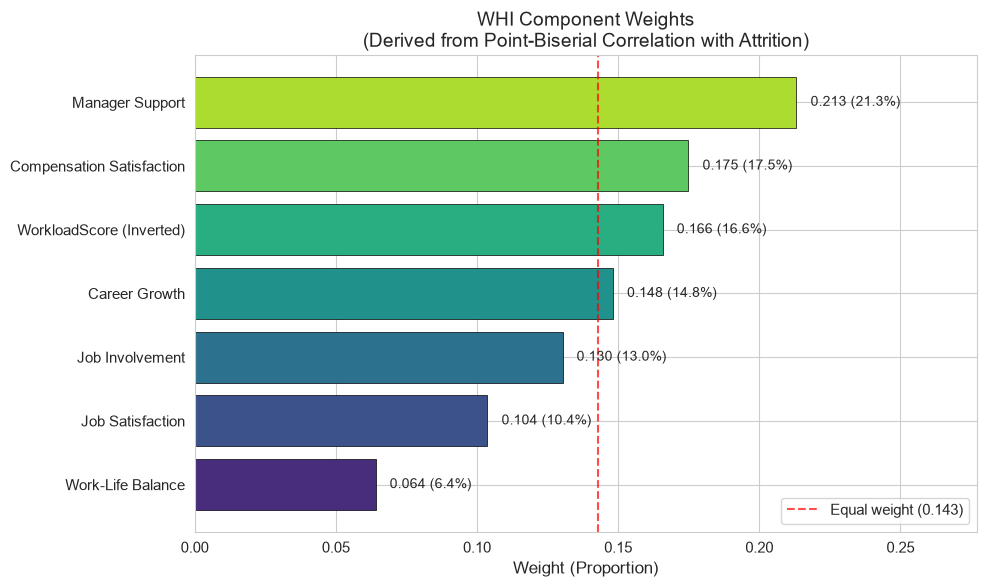


The red dashed line shows where equal weighting (1/7) would place each variable.
Variables to the right of the line are more important than equal weighting would suggest.


In [11]:
# Visualize weights
fig, ax = plt.subplots(figsize=(10, 6))

weight_table_sorted = weight_table.sort_values('Weight', ascending=True)
bars = ax.barh(
    weight_table_sorted['Variable'],
    weight_table_sorted['Weight'],
    color=sns.color_palette('viridis', n_colors=len(weight_table_sorted)),
    edgecolor='black',
    linewidth=0.5
)

# Add value labels
for bar, weight_val in zip(bars, weight_table_sorted['Weight']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{weight_val:.3f} ({weight_val*100:.1f}%)',
            va='center', fontsize=10)

ax.set_xlabel('Weight (Proportion)')
ax.set_title('WHI Component Weights\n(Derived from Point-Biserial Correlation with Attrition)')
ax.axvline(x=1/7, color='red', linestyle='--', alpha=0.7, label=f'Equal weight ({1/7:.3f})')
ax.legend(loc='lower right')
ax.set_xlim(0, weight_table['Weight'].max() * 1.3)

plt.tight_layout()
plt.show()

print('\nThe red dashed line shows where equal weighting (1/7) would place each variable.')
print('Variables to the right of the line are more important than equal weighting would suggest.')

---

## 5. WHI Computation

### Formula

The Workforce Health Index is computed as:

$$WHI = \left( \sum_{i=1}^{7} w_i \cdot X_i^{norm} \right) \times 100$$

Where:
- $w_i$ = weight for variable $i$ (derived from point-biserial correlation, summing to 1)
- $X_i^{norm}$ = Min-Max normalized value of variable $i$ (range 0-1)
- The multiplication by 100 scales the index to a 0-100 range for interpretability

### Interpretation
- **WHI = 100**: Maximum possible workforce health (all dimensions at their best)
- **WHI = 0**: Minimum possible workforce health (all dimensions at their worst)
- **Higher WHI** indicates a healthier, more engaged, better-supported employee

In [12]:
# Compute WHI
# WHI = sum(normalized_variable_i * weight_i) * 100

df['WHI'] = 0.0

print('WHI Computation:')
print('WHI = (', end='')
terms = []
for norm_col, (orig_col, label) in zip(normalized_cols, variables_for_normalization.items()):
    w = weights[norm_col]
    df['WHI'] += df[norm_col] * w
    terms.append(f'{w:.4f} * {label}')

print(' + '.join(terms[:3]))
print('       + ' + ' + '.join(terms[3:5]))
print('       + ' + ' + '.join(terms[5:]))
print(') * 100')

# Scale to 0-100
df['WHI'] = df['WHI'] * 100

print(f'\nWHI computed for all {len(df)} employees.')
print(f'\nWHI Descriptive Statistics:')
print(f'  Mean:   {df["WHI"].mean():.2f}')
print(f'  Median: {df["WHI"].median():.2f}')
print(f'  Std:    {df["WHI"].std():.2f}')
print(f'  Min:    {df["WHI"].min():.2f}')
print(f'  Max:    {df["WHI"].max():.2f}')
print(f'  IQR:    {df["WHI"].quantile(0.25):.2f} - {df["WHI"].quantile(0.75):.2f}')

WHI Computation:
WHI = (0.1658 * WorkloadScore (Inverted) + 0.0641 * Work-Life Balance + 0.2132 * Manager Support
       + 0.1481 * Career Growth + 0.1037 * Job Satisfaction
       + 0.1749 * Compensation Satisfaction + 0.1303 * Job Involvement
) * 100

WHI computed for all 1470 employees.

WHI Descriptive Statistics:
  Mean:   56.01
  Median: 56.26
  Std:    10.02
  Min:    25.82
  Max:    84.46
  IQR:    49.22 - 62.80


---

## 6. Distribution Analysis

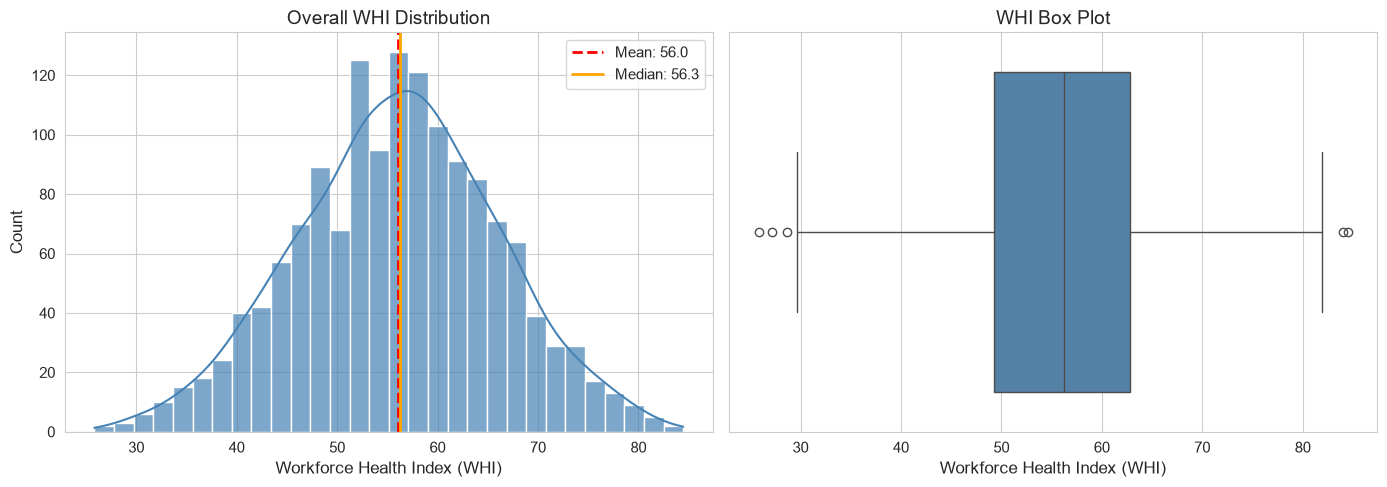

In [13]:
# 6.1 Overall WHI Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
ax1 = axes[0]
sns.histplot(df['WHI'], bins=30, kde=True, ax=ax1, color='steelblue', alpha=0.7)
ax1.axvline(df['WHI'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["WHI"].mean():.1f}')
ax1.axvline(df['WHI'].median(), color='orange', linestyle='-', linewidth=2, label=f'Median: {df["WHI"].median():.1f}')
ax1.set_xlabel('Workforce Health Index (WHI)')
ax1.set_ylabel('Count')
ax1.set_title('Overall WHI Distribution')
ax1.legend()

# Box plot
ax2 = axes[1]
sns.boxplot(x=df['WHI'], ax=ax2, color='steelblue')
ax2.set_xlabel('Workforce Health Index (WHI)')
ax2.set_title('WHI Box Plot')

plt.tight_layout()
plt.show()

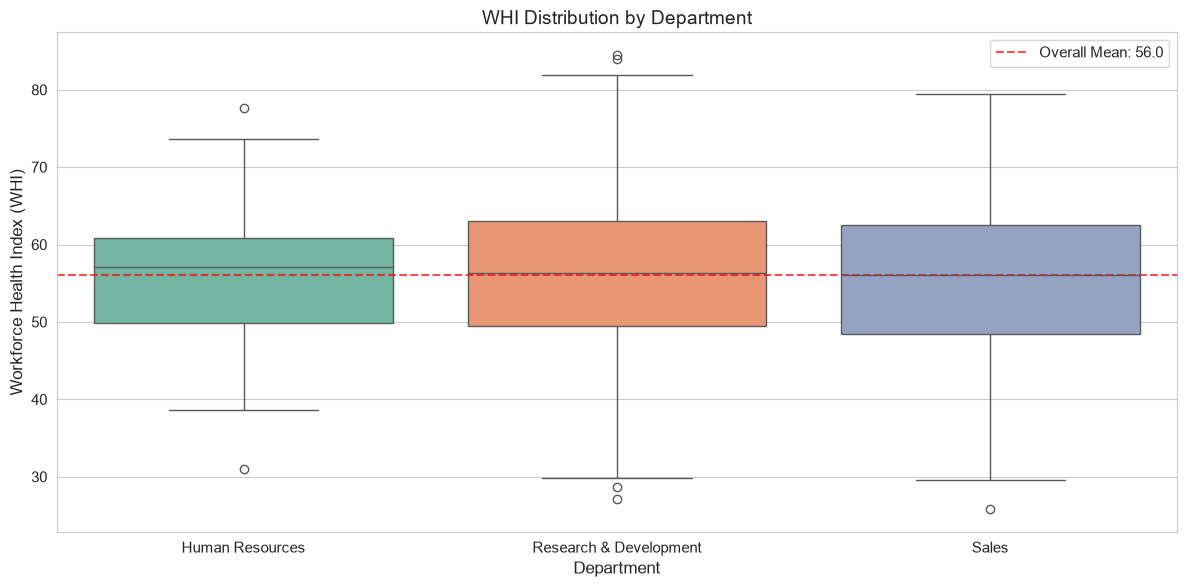


WHI by Department:
                          mean  median     std  count
Department                                           
Research & Development 56.1800 56.3300 10.1100    961
Human Resources        55.9900 57.0400  8.4400     63
Sales                  55.6400 56.1000 10.0200    446


In [14]:
# 6.2 WHI by Department
fig, ax = plt.subplots(figsize=(12, 6))

dept_order = df.groupby('Department')['WHI'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df, x='Department', y='WHI', order=dept_order,
    palette='Set2', ax=ax
)

ax.set_xlabel('Department')
ax.set_ylabel('Workforce Health Index (WHI)')
ax.set_title('WHI Distribution by Department')
ax.axhline(df['WHI'].mean(), color='red', linestyle='--', alpha=0.7, label=f'Overall Mean: {df["WHI"].mean():.1f}')
ax.legend()

plt.tight_layout()
plt.show()

# Department statistics
print('\nWHI by Department:')
print('=' * 60)
dept_stats = df.groupby('Department')['WHI'].agg(['mean', 'median', 'std', 'count'])
dept_stats = dept_stats.sort_values('mean', ascending=False)
print(dept_stats.round(2))

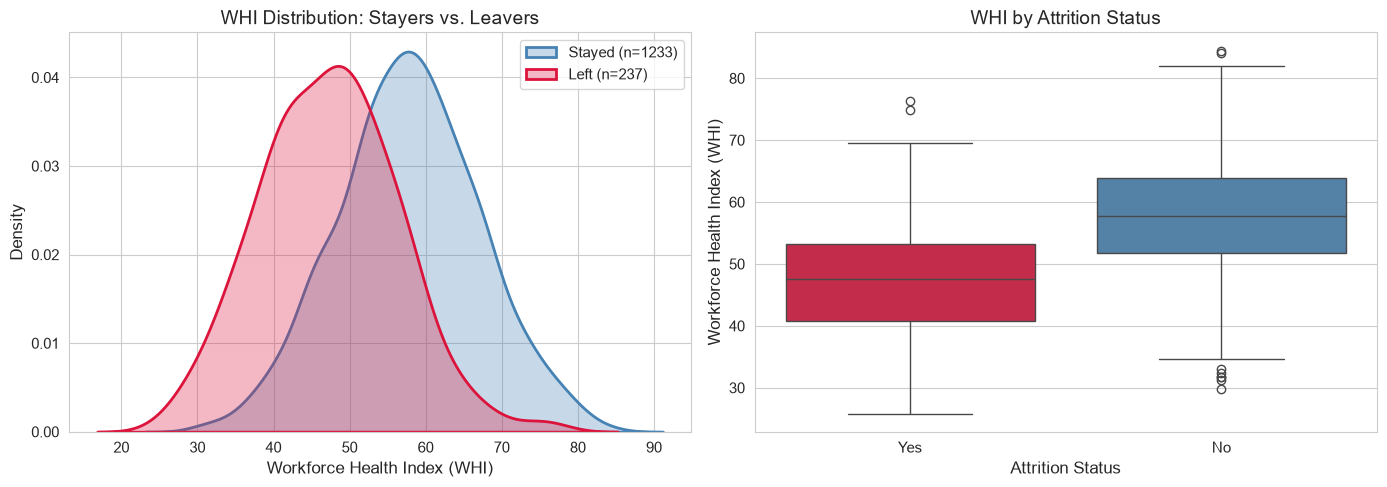


WHI by Attrition Status:
             mean  median    std     min     max
Attrition                                       
No        57.7000 57.7400 9.3000 29.8500 84.4600
Yes       47.2200 47.6100 8.9500 25.8200 76.2600

Difference in means: 10.48 points
Employees who left had WHI scores 10.5 points lower on average.


In [15]:
# 6.3 WHI by Attrition Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE comparison
ax1 = axes[0]
for status, color, label in [('No', 'steelblue', 'Stayed'), ('Yes', 'crimson', 'Left')]:
    subset = df[df['Attrition'] == status]['WHI']
    sns.kdeplot(subset, ax=ax1, color=color, label=f'{label} (n={len(subset)})', linewidth=2, fill=True, alpha=0.3)

ax1.set_xlabel('Workforce Health Index (WHI)')
ax1.set_ylabel('Density')
ax1.set_title('WHI Distribution: Stayers vs. Leavers')
ax1.legend(fontsize=11)

# Box plot comparison
ax2 = axes[1]
sns.boxplot(data=df, x='Attrition', y='WHI', palette={'No': 'steelblue', 'Yes': 'crimson'}, ax=ax2)
ax2.set_xlabel('Attrition Status')
ax2.set_ylabel('Workforce Health Index (WHI)')
ax2.set_title('WHI by Attrition Status')

plt.tight_layout()
plt.show()

# Statistics
print('\nWHI by Attrition Status:')
print('=' * 60)
att_stats = df.groupby('Attrition')['WHI'].agg(['mean', 'median', 'std', 'min', 'max'])
print(att_stats.round(2))
print(f'\nDifference in means: {att_stats.loc["No", "mean"] - att_stats.loc["Yes", "mean"]:.2f} points')
print(f'Employees who left had WHI scores {att_stats.loc["No", "mean"] - att_stats.loc["Yes", "mean"]:.1f} points lower on average.')

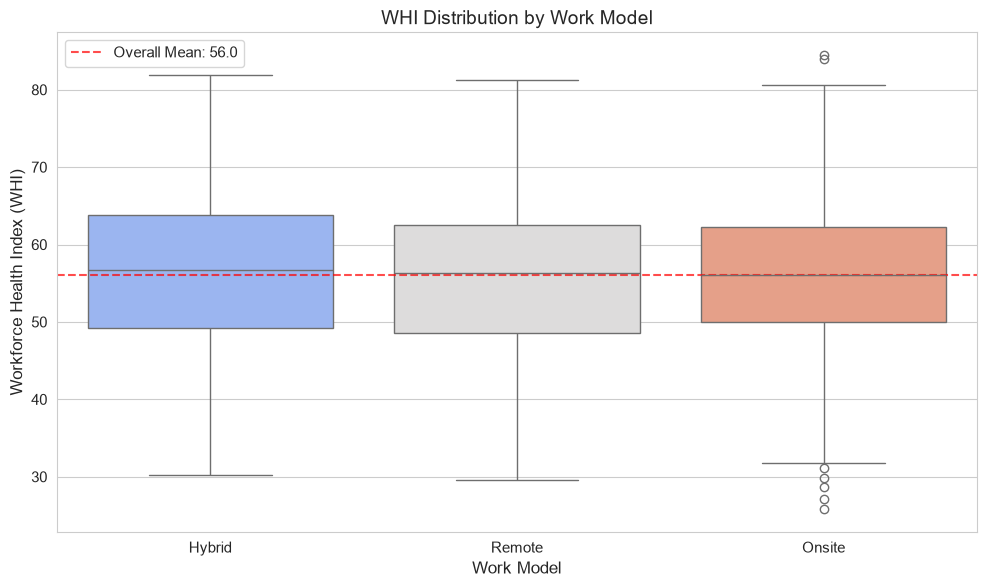


WHI by Work Model:
             mean  median     std  count
WorkModel                               
Hybrid    56.5800 56.6500  9.9800    509
Remote    55.7200 56.2900 10.3400    314
Onsite    55.7100 56.0200  9.8800    647


In [16]:
# 6.4 WHI by Work Model
fig, ax = plt.subplots(figsize=(10, 6))

work_model_order = df.groupby('WorkModel')['WHI'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df, x='WorkModel', y='WHI', order=work_model_order,
    palette='coolwarm', ax=ax
)

ax.set_xlabel('Work Model')
ax.set_ylabel('Workforce Health Index (WHI)')
ax.set_title('WHI Distribution by Work Model')
ax.axhline(df['WHI'].mean(), color='red', linestyle='--', alpha=0.7, label=f'Overall Mean: {df["WHI"].mean():.1f}')
ax.legend()

plt.tight_layout()
plt.show()

# Work Model statistics
print('\nWHI by Work Model:')
print('=' * 60)
wm_stats = df.groupby('WorkModel')['WHI'].agg(['mean', 'median', 'std', 'count'])
wm_stats = wm_stats.sort_values('mean', ascending=False)
print(wm_stats.round(2))

In [17]:
# 6.5 Complete Descriptive Statistics
print('Complete WHI Descriptive Statistics:')
print('=' * 50)
print(df['WHI'].describe().round(2))
print(f'\nSkewness:  {df["WHI"].skew():.4f}')
print(f'Kurtosis:  {df["WHI"].kurtosis():.4f}')
print(f'\nPercentiles:')
for pct in [5, 10, 25, 50, 75, 90, 95]:
    print(f'  P{pct:>2}: {df["WHI"].quantile(pct/100):.2f}')

Complete WHI Descriptive Statistics:
count   1470.0000
mean      56.0100
std       10.0200
min       25.8200
25%       49.2200
50%       56.2600
75%       62.8000
max       84.4600
Name: WHI, dtype: float64

Skewness:  -0.0595
Kurtosis:  -0.1716

Percentiles:
  P 5: 39.28
  P10: 42.84
  P25: 49.22
  P50: 56.26
  P75: 62.80
  P90: 68.68
  P95: 72.74


---

## 7. Validation

A composite index is only useful if it meaningfully relates to real outcomes. We validate the WHI using two approaches:

1. **Mann-Whitney U Test**: Non-parametric test to determine if the WHI distributions of leavers and stayers are statistically different
2. **ROC Analysis**: Evaluate the WHI's discriminative ability as a predictor of attrition

In [18]:
# 7.1 Mann-Whitney U Test
whi_stayers = df[df['Attrition'] == 'No']['WHI']
whi_leavers = df[df['Attrition'] == 'Yes']['WHI']

u_stat, p_value = mannwhitneyu(whi_stayers, whi_leavers, alternative='two-sided')

# Effect size (rank-biserial correlation)
n1, n2 = len(whi_stayers), len(whi_leavers)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

print('Mann-Whitney U Test: WHI of Stayers vs. Leavers')
print('=' * 60)
print(f'  Stayers: n={n1}, median WHI={whi_stayers.median():.2f}')
print(f'  Leavers: n={n2}, median WHI={whi_leavers.median():.2f}')
print(f'\n  U statistic: {u_stat:.0f}')
print(f'  p-value: {p_value:.2e}')
print(f'  Rank-biserial correlation (effect size): {rank_biserial:.4f}')
print(f'\n  Conclusion: ', end='')
if p_value < 0.001:
    print('HIGHLY SIGNIFICANT (p < 0.001)')
    print('  The WHI distributions of stayers and leavers are statistically')
    print('  significantly different. The WHI effectively differentiates between groups.')
elif p_value < 0.05:
    print('SIGNIFICANT (p < 0.05)')
    print('  The WHI shows statistically significant differences between groups.')
else:
    print('NOT SIGNIFICANT (p >= 0.05)')
    print('  The WHI does not significantly differentiate between groups.')

Mann-Whitney U Test: WHI of Stayers vs. Leavers
  Stayers: n=1233, median WHI=57.74
  Leavers: n=237, median WHI=47.61

  U statistic: 231730
  p-value: 2.02e-46
  Rank-biserial correlation (effect size): -0.5860

  Conclusion: HIGHLY SIGNIFICANT (p < 0.001)
  The WHI distributions of stayers and leavers are statistically
  significantly different. The WHI effectively differentiates between groups.


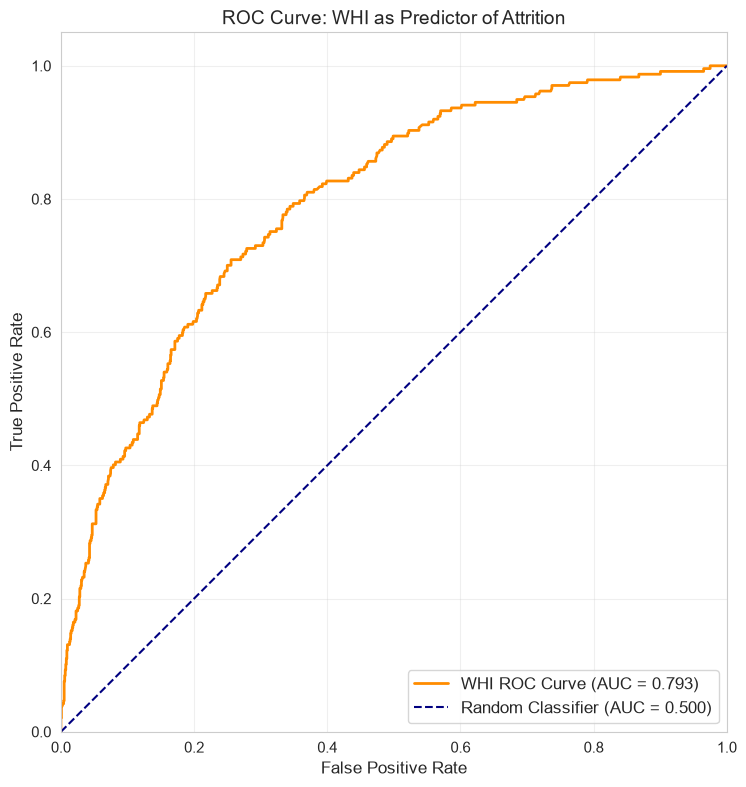


ROC Analysis Results:
  AUC = 0.793

  Interpretation:
  Good discriminative ability (AUC >= 0.70).

  The WHI correctly ranks a randomly chosen leaver as having lower
  workforce health than a randomly chosen stayer 79.3% of the time.


In [19]:
# 7.2 ROC Curve Analysis
# WHI as predictor of attrition (lower WHI -> higher risk of attrition)
# We invert WHI for ROC since lower WHI predicts attrition (positive class)
fpr, tpr, thresholds = roc_curve(df['Attrition_Binary'], -df['WHI'])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'WHI ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier (AUC = 0.500)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: WHI as Predictor of Attrition')
ax.legend(loc='lower right', fontsize=12)
ax.set_aspect('equal')

# Add grid
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nROC Analysis Results:')
print(f'  AUC = {roc_auc:.3f}')
print(f'\n  Interpretation:')
if roc_auc >= 0.8:
    print(f'  Excellent discriminative ability (AUC >= 0.80).')
elif roc_auc >= 0.7:
    print(f'  Good discriminative ability (AUC >= 0.70).')
elif roc_auc >= 0.6:
    print(f'  Moderate discriminative ability (AUC >= 0.60).')
else:
    print(f'  Poor discriminative ability (AUC < 0.60).')
print(f'\n  The WHI correctly ranks a randomly chosen leaver as having lower')
print(f'  workforce health than a randomly chosen stayer {roc_auc*100:.1f}% of the time.')

---

## 8. Risk Categories

To make the WHI actionable for managers and HR, we define five risk categories with clear intervention implications:

| Category | WHI Range | Interpretation | Action Required |
|----------|-----------|---------------|-----------------|
| Critical | < 30 | Severe disengagement; high flight risk | Immediate 1:1 intervention |
| At Risk | 30 - 49 | Concerning decline in well-being | Priority check-in within 2 weeks |
| Moderate | 50 - 69 | Acceptable but room for improvement | Standard engagement programs |
| Healthy | 70 - 84 | Positive employee experience | Maintain current practices |
| Thriving | >= 85 | Exceptional engagement and satisfaction | Leverage as mentors/ambassadors |

In [20]:
# Define risk categories
def assign_risk_category(whi):
    if whi < 30:
        return 'Critical'
    elif whi < 50:
        return 'At Risk'
    elif whi < 70:
        return 'Moderate'
    elif whi < 85:
        return 'Healthy'
    else:
        return 'Thriving'

df['WHI_Risk_Category'] = df['WHI'].apply(assign_risk_category)

# Define category order for consistent display
category_order = ['Critical', 'At Risk', 'Moderate', 'Healthy', 'Thriving']
category_colors = {'Critical': '#d62728', 'At Risk': '#ff7f0e', 'Moderate': '#ffd700', 
                   'Healthy': '#2ca02c', 'Thriving': '#1f77b4'}

# Distribution across categories
print('WHI Risk Category Distribution:')
print('=' * 70)
print(f'{"Category":<12} {"Count":<8} {"Percentage":<12} {"WHI Range"}')
print('-' * 70)

for cat in category_order:
    count = (df['WHI_Risk_Category'] == cat).sum()
    pct = count / len(df) * 100
    cat_data = df[df['WHI_Risk_Category'] == cat]['WHI']
    if len(cat_data) > 0:
        print(f'{cat:<12} {count:<8} {pct:>6.1f}%      [{cat_data.min():.1f} - {cat_data.max():.1f}]')
    else:
        print(f'{cat:<12} {count:<8} {pct:>6.1f}%      [N/A]')

WHI Risk Category Distribution:
Category     Count    Percentage   WHI Range
----------------------------------------------------------------------
Critical     7           0.5%      [25.8 - 29.9]


At Risk      391        26.6%      [30.2 - 50.0]
Moderate     956        65.0%      [50.0 - 69.9]
Healthy      116         7.9%      [70.0 - 84.5]
Thriving     0           0.0%      [N/A]


In [21]:
# Attrition rate per risk category
print('\nAttrition Rate by WHI Risk Category:')
print('=' * 70)
print(f'{"Category":<12} {"Total":<8} {"Left":<8} {"Stayed":<8} {"Attrition Rate"}')
print('-' * 70)

attrition_by_category = []
for cat in category_order:
    cat_df = df[df['WHI_Risk_Category'] == cat]
    total = len(cat_df)
    left = (cat_df['Attrition'] == 'Yes').sum()
    stayed = total - left
    rate = left / total * 100 if total > 0 else 0
    attrition_by_category.append({'Category': cat, 'Total': total, 'Left': left, 
                                   'Stayed': stayed, 'Attrition Rate': rate})
    print(f'{cat:<12} {total:<8} {left:<8} {stayed:<8} {rate:>6.1f}%')

attrition_cat_df = pd.DataFrame(attrition_by_category)
print(f'\nOverall attrition rate: {df["Attrition_Binary"].mean()*100:.1f}%')


Attrition Rate by WHI Risk Category:
Category     Total    Left     Stayed   Attrition Rate
----------------------------------------------------------------------
Critical     7        6        1          85.7%
At Risk      391      141      250        36.1%
Moderate     956      88       868         9.2%
Healthy      116      2        114         1.7%
Thriving     0        0        0           0.0%

Overall attrition rate: 16.1%


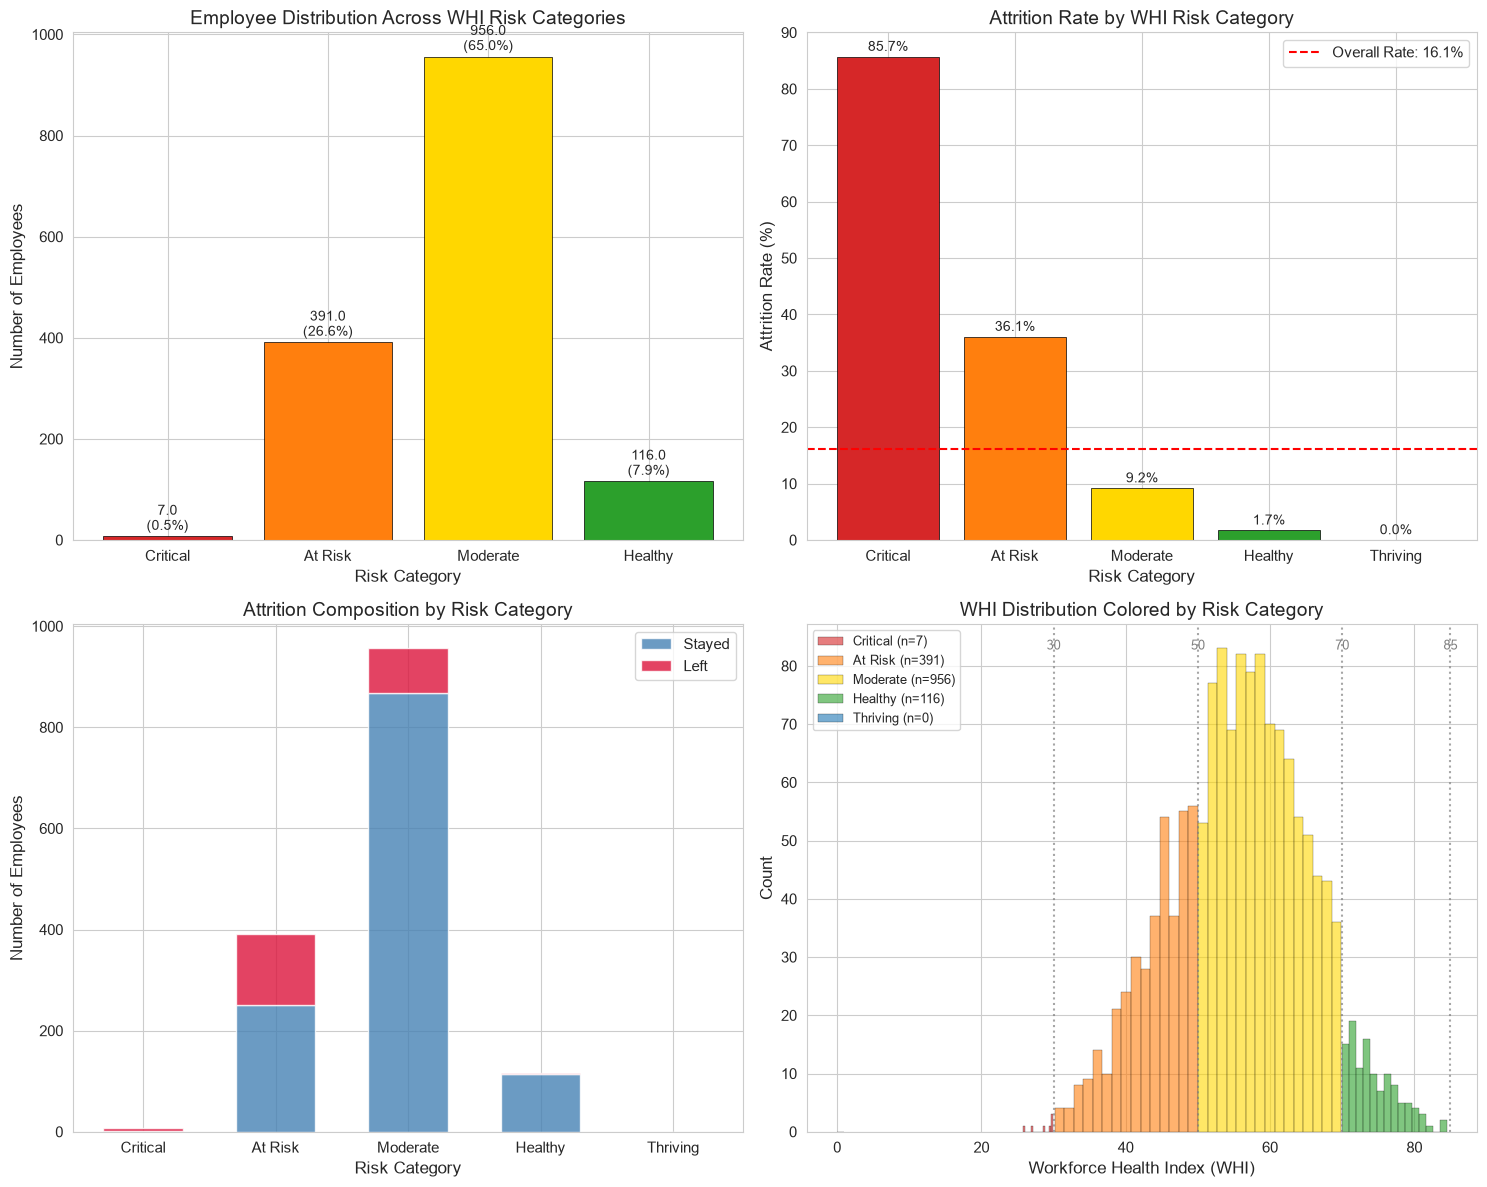

In [22]:
# Visualization: Risk Categories
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 8a. Category distribution (bar chart)
ax1 = axes[0, 0]
cat_counts = df['WHI_Risk_Category'].value_counts().reindex(category_order)
bars = ax1.bar(category_order, cat_counts.values, 
               color=[category_colors[c] for c in category_order],
               edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Risk Category')
ax1.set_ylabel('Number of Employees')
ax1.set_title('Employee Distribution Across WHI Risk Categories')
for bar, count in zip(bars, cat_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)

# 8b. Attrition rate by category
ax2 = axes[0, 1]
bars2 = ax2.bar(attrition_cat_df['Category'], attrition_cat_df['Attrition Rate'],
                color=[category_colors[c] for c in attrition_cat_df['Category']],
                edgecolor='black', linewidth=0.5)
ax2.axhline(df['Attrition_Binary'].mean()*100, color='red', linestyle='--', 
            label=f'Overall Rate: {df["Attrition_Binary"].mean()*100:.1f}%')
ax2.set_xlabel('Risk Category')
ax2.set_ylabel('Attrition Rate (%)')
ax2.set_title('Attrition Rate by WHI Risk Category')
ax2.legend()
for bar, rate in zip(bars2, attrition_cat_df['Attrition Rate']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{rate:.1f}%', ha='center', va='bottom', fontsize=10)

# 8c. Stacked bar: Stayed vs Left per category
ax3 = axes[1, 0]
x = np.arange(len(category_order))
width = 0.6
stayed_vals = attrition_cat_df['Stayed'].values
left_vals = attrition_cat_df['Left'].values

ax3.bar(x, stayed_vals, width, label='Stayed', color='steelblue', alpha=0.8)
ax3.bar(x, left_vals, width, bottom=stayed_vals, label='Left', color='crimson', alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(category_order)
ax3.set_xlabel('Risk Category')
ax3.set_ylabel('Number of Employees')
ax3.set_title('Attrition Composition by Risk Category')
ax3.legend()

# 8d. WHI histogram colored by risk category
ax4 = axes[1, 1]
for cat in category_order:
    cat_data = df[df['WHI_Risk_Category'] == cat]['WHI']
    ax4.hist(cat_data, bins=15, alpha=0.6, label=f'{cat} (n={len(cat_data)})',
             color=category_colors[cat], edgecolor='black', linewidth=0.3)

# Add vertical lines for thresholds
for threshold, label in [(30, '30'), (50, '50'), (70, '70'), (85, '85')]:
    ax4.axvline(threshold, color='gray', linestyle=':', alpha=0.7)
    ax4.text(threshold, ax4.get_ylim()[1]*0.95, label, ha='center', fontsize=9, color='gray')

ax4.set_xlabel('Workforce Health Index (WHI)')
ax4.set_ylabel('Count')
ax4.set_title('WHI Distribution Colored by Risk Category')
ax4.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

---

## 9. Save Enhanced Dataset

We save the dataset with the WHI score and risk category added, so these can be used in subsequent analyses and dashboards.

In [23]:
# Prepare columns to save
# Keep WHI and WHI_Risk_Category, remove intermediate columns
cols_to_drop = ['Attrition_Binary', 'WorkloadScore_Inverted'] + normalized_cols
df_save = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Verify WHI columns are present
print('Columns being saved that are new:')
print(f'  WHI: {"WHI" in df_save.columns}')
print(f'  WHI_Risk_Category: {"WHI_Risk_Category" in df_save.columns}')
print(f'\nDataset shape: {df_save.shape}')
print(f'\nSample of WHI values:')
print(df_save[['Age', 'Department', 'JobRole', 'Attrition', 'WHI', 'WHI_Risk_Category']].head(10))

Columns being saved that are new:
  WHI: True
  WHI_Risk_Category: True

Dataset shape: (1470, 45)

Sample of WHI values:
   Age              Department                    JobRole Attrition     WHI  \
0   41                   Sales            Sales Executive       Yes 43.7855   
1   49  Research & Development         Research Scientist        No 64.9456   
2   37  Research & Development      Laboratory Technician       Yes 33.5917   
3   33  Research & Development         Research Scientist        No 48.3041   
4   27  Research & Development      Laboratory Technician        No 50.5543   
5   32  Research & Development      Laboratory Technician        No 66.9458   
6   59  Research & Development      Laboratory Technician        No 44.7204   
7   30  Research & Development      Laboratory Technician        No 61.4809   
8   38  Research & Development     Manufacturing Director        No 64.0296   
9   36  Research & Development  Healthcare Representative        No 62.0924   

  WHI_Ri

In [24]:
# Save to CSV
output_path = '../data/processed/employee_attrition_augmented.csv'
df_save.to_csv(output_path, index=False)

print(f'Enhanced dataset saved to: {output_path}')
print(f'Total rows: {len(df_save)}')
print(f'Total columns: {df_save.shape[1]}')
print(f'\nNew columns added:')
print(f'  - WHI (Workforce Health Index, 0-100 scale)')
print(f'  - WHI_Risk_Category (Critical/At Risk/Moderate/Healthy/Thriving)')

Enhanced dataset saved to: ../data/processed/employee_attrition_augmented.csv
Total rows: 1470
Total columns: 45

New columns added:
  - WHI (Workforce Health Index, 0-100 scale)
  - WHI_Risk_Category (Critical/At Risk/Moderate/Healthy/Thriving)


---

## 10. Documentation and Summary

### WHI Formula

$$WHI = \left( \sum_{i=1}^{7} w_i \cdot \frac{X_i - X_i^{min}}{X_i^{max} - X_i^{min}} \right) \times 100$$

Where:
- $X_1$ = WorkloadScore (inverted: $6 - \text{WorkloadScore}$)
- $X_2$ = WorkLifeBalance
- $X_3$ = ManagerSupportScore
- $X_4$ = CareerGrowthPerception
- $X_5$ = JobSatisfaction
- $X_6$ = CompensationSatisfaction
- $X_7$ = JobInvolvement
- $w_i$ = data-driven weight from point-biserial correlation with attrition
- $X_i^{min}$, $X_i^{max}$ = actual minimum and maximum values from the data

### Key Assumptions

1. **Linearity**: The relationship between each component and workforce health is assumed to be linear within its observed range.

2. **Additivity**: The total workforce health is the weighted sum of components -- no interaction effects are modeled.

3. **Stationarity**: The weights derived from current data are assumed to remain valid over time. In practice, weights should be recalibrated periodically.

4. **Completeness**: The seven selected dimensions are assumed to capture the major aspects of workforce health. Other unmeasured factors (e.g., team dynamics, commute stress) are not included.

5. **Scale validity**: The underlying survey instruments are assumed to produce valid, reliable measurements.

### Limitations

1. **Correlation-based weights**: Point-biserial correlation captures linear relationships only. Non-linear associations between variables and attrition may be underweighted.

2. **Retrospective validation**: The WHI is validated against historical attrition. Its predictive power for future attrition requires prospective validation.

3. **Threshold sensitivity**: The risk category boundaries (30, 50, 70, 85) are informed by the distribution but are ultimately judgment calls. They should be refined based on operational experience.

4. **Population specificity**: Weights and normalization parameters are specific to this workforce. Applying the WHI to a different organization without recalibration may yield misleading results.

5. **Single timepoint**: The current WHI is a snapshot. Trends over time (rising or falling WHI) may be more informative than absolute levels.

6. **No causal claims**: A low WHI is associated with higher attrition risk but does not necessarily cause it. Common causes or reverse causation are possible.

### Business Implications

1. **Early Warning System**: The WHI provides a quantitative early-warning signal. Employees entering the "Critical" or "At Risk" categories should trigger proactive manager outreach.

2. **Resource Allocation**: Departments or teams with lower average WHI scores should be prioritized for engagement interventions, manager training, or workload rebalancing.

3. **Program Evaluation**: The WHI can serve as a pre/post metric for evaluating the effectiveness of wellness programs, policy changes, or leadership initiatives.

4. **Benchmarking**: Cross-department and cross-team comparisons using WHI enable data-driven conversations about organizational health differences.

5. **Retention ROI**: By linking WHI categories to attrition rates, organizations can estimate the cost savings from moving employees from "At Risk" to "Moderate" or above.

6. **Continuous Monitoring**: Implementing WHI as a recurring metric (e.g., quarterly pulse surveys) enables trend detection and early intervention before critical mass is reached.

In [25]:
# Final Summary
print('=' * 70)
print('WORKFORCE HEALTH INDEX (WHI) - SUMMARY')
print('=' * 70)
print(f'\nDataset: {len(df)} employees')
print(f'Components: 7 dimensions (workload, balance, manager support,')
print(f'            career growth, job satisfaction, compensation, involvement)')
print(f'Weighting: Point-biserial correlation with attrition')
print(f'Scale: 0-100')
print(f'\nOverall WHI Statistics:')
print(f'  Mean:   {df["WHI"].mean():.2f}')
print(f'  Median: {df["WHI"].median():.2f}')
print(f'  Std:    {df["WHI"].std():.2f}')
print(f'\nValidation:')
print(f'  Mann-Whitney U p-value: {p_value:.2e}')
print(f'  ROC AUC: {roc_auc:.3f}')
print(f'\nRisk Category Distribution:')
for cat in category_order:
    count = (df['WHI_Risk_Category'] == cat).sum()
    rate = df[df['WHI_Risk_Category'] == cat]['Attrition_Binary'].mean() * 100
    print(f'  {cat:<12}: {count:>4} employees ({count/len(df)*100:>5.1f}%) | Attrition: {rate:.1f}%')
print(f'\nOutput: Enhanced dataset saved with WHI and WHI_Risk_Category columns.')
print('=' * 70)

WORKFORCE HEALTH INDEX (WHI) - SUMMARY

Dataset: 1470 employees
Components: 7 dimensions (workload, balance, manager support,
            career growth, job satisfaction, compensation, involvement)
Weighting: Point-biserial correlation with attrition
Scale: 0-100

Overall WHI Statistics:
  Mean:   56.01
  Median: 56.26
  Std:    10.02

Validation:
  Mann-Whitney U p-value: 2.02e-46
  ROC AUC: 0.793

Risk Category Distribution:
  Critical    :    7 employees (  0.5%) | Attrition: 85.7%
  At Risk     :  391 employees ( 26.6%) | Attrition: 36.1%
  Moderate    :  956 employees ( 65.0%) | Attrition: 9.2%
  Healthy     :  116 employees (  7.9%) | Attrition: 1.7%
  Thriving    :    0 employees (  0.0%) | Attrition: nan%

Output: Enhanced dataset saved with WHI and WHI_Risk_Category columns.
